In [1]:
import pandas as pd
import os
MIMIC_DATA_PATH = '/home/chufan2/github/ehr_syn_repro/'
train_patients_path = '/home/chufan2/github/ehr_syn_repro/data/train_patient_ids.txt'
test_patients_path = '/home/chufan2/github/ehr_syn_repro/data/test_patient_ids.txt'

admissions_df = pd.read_csv(MIMIC_DATA_PATH + 'ADMISSIONS.csv')
patients_df = pd.read_csv(MIMIC_DATA_PATH + 'PATIENTS.csv')
diagnoses_df = pd.read_csv(MIMIC_DATA_PATH + 'DIAGNOSES_ICD.csv')

print(f"Admissions shape: {admissions_df.shape}")
print(f"Patients shape: {patients_df.shape}")
print(f"Diagnoses shape: {diagnoses_df.shape}")

admissions_df['ADMITTIME'] = pd.to_datetime(admissions_df['ADMITTIME'])
patients_df['DOB'] = pd.to_datetime(patients_df['DOB'])
# Calculate age at first admission
first_admissions = admissions_df.loc[
    admissions_df.groupby('SUBJECT_ID')['ADMITTIME'].idxmin()
][['SUBJECT_ID', 'ADMITTIME']]

demo_df = pd.merge(
    patients_df[['SUBJECT_ID', 'GENDER', 'DOB', 'EXPIRE_FLAG']],
    first_admissions,
    on='SUBJECT_ID',
    how='inner'
)

demo_df['AGE'] = (demo_df['ADMITTIME'].dt.year - demo_df['DOB'].dt.year)
demo_df['AGE'] = demo_df['AGE'].apply(lambda x: 90 if x > 89 else x)

# Merge admissions with diagnoses
admissions_info = admissions_df[['SUBJECT_ID', 'HADM_ID', 'ADMITTIME']]
merged_df = pd.merge(
    admissions_info,
    diagnoses_df[['SUBJECT_ID', 'HADM_ID', 'ICD9_CODE',]],
    on=['SUBJECT_ID', 'HADM_ID'],
    how='inner'
)

# Merge with demographics
final_df = pd.merge(
    merged_df,
    demo_df[['SUBJECT_ID', 'AGE', 'GENDER', 'EXPIRE_FLAG']],
    on='SUBJECT_ID',
    how='left'
)

# Sort chronologically
final_df.sort_values(by=['SUBJECT_ID', 'ADMITTIME',], inplace=True)

# map all HADM_ID to sequential visit IDs per SUBJECT_ID, starting from 0
final_df["VISIT_ID"] = final_df.groupby("SUBJECT_ID")["HADM_ID"].transform(lambda x: pd.factorize(x)[0])

final_df['SUBJECT_ID'] = final_df['SUBJECT_ID'].astype(str)
final_df['HADM_ID'] = final_df['HADM_ID'].astype(float)
final_df['ICD9_CODE'] = final_df['ICD9_CODE'].astype(str)

# split by train and test
train_patient_ids = pd.read_csv(train_patients_path, header=None)[0].astype(str)
test_patients_ids = pd.read_csv(test_patients_path, header=None)[0].astype(str)
train_ehr = final_df[final_df['SUBJECT_ID'].isin(train_patient_ids)].reset_index(drop=True)
test_ehr = final_df[final_df['SUBJECT_ID'].isin(test_patients_ids)].reset_index(drop=True)
# # Top 10 ICD9 codes correlated with EXPIRE_FLAG: ['1560', '1965', '85225', '1986', '1972', 'V667', '1519', '2387', '07041', '73741']
# top_10_codes = ['1560', '1965', '85225', '1986', '1972', 'V667', '1519', '2387', '07041', '73741']

print(train_ehr.shape, test_ehr.shape)
print(train_ehr['SUBJECT_ID'].nunique(), test_ehr['SUBJECT_ID'].nunique())
print(train_ehr.groupby('SUBJECT_ID')['VISIT_ID'].nunique().max(), train_ehr.groupby('SUBJECT_ID')['VISIT_ID'].nunique().mean())
print(train_ehr['ICD9_CODE'].nunique(), test_ehr['ICD9_CODE'].nunique())

train_ehr_flattened = train_ehr.copy()
train_ehr_flattened['HADM_ID'] = 1
test_ehr_flattened = test_ehr.copy()
test_ehr_flattened['HADM_ID'] = 1

Admissions shape: (58976, 19)
Patients shape: (46520, 8)
Diagnoses shape: (651047, 5)
(637161, 8) (13886, 8)
45520 1000
42 1.2682117750439368
6956 1997


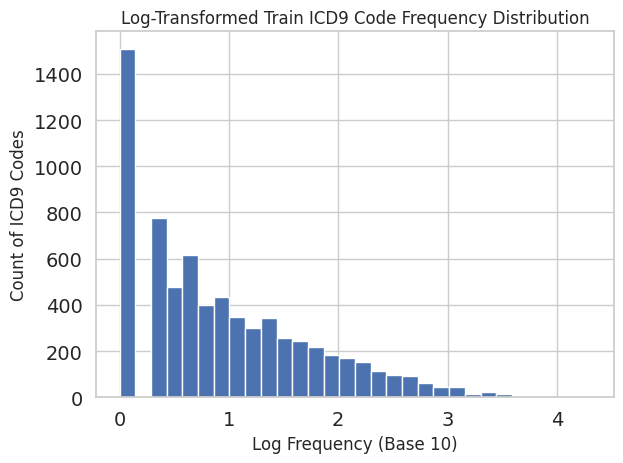

In [2]:
# make it log scale plot, make it sns
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
train_ehr['ICD9_CODE'].value_counts().apply(np.log10).plot(
    kind='hist', bins=30,
    title='Log-Transformed Train ICD9 Code Frequency Distribution',
    xlabel='Log Frequency (Base 10)', ylabel='Count of ICD9 Codes',
    fontsize=14,
    )
plt.tight_layout()
plt.savefig('imgs/train_icd9_code_freq_distribution.pdf')

In [ ]:
%load_ext autoreload
%autoreload 2

from eval_utils import calculate_all_metrics

long_tailed_ablation = False
regular_evaluation = True

base_path = '/home/chufan2/github/ehr_syn_repro/data/'
all_metrics = []
for path in [
    base_path+'synthetic_10k_halo.csv',
    base_path+'synthetic_10k_medgan.csv', 
    base_path+'synthetic_10k_corgan.csv', 
    base_path+'synthetic_10k_promptehr.csv',
    '/home/chufan2/github/ehr_syn_repro/synthetic_data/transformer_baseline/transformer_baseline_synthetic_ehr.csv'
    ]:
    
    # syn_ehr_path = base_path + path
    syn_ehr_df = pd.read_csv(path)
    if 'corgan' in os.path.basename(path) or 'medgan' in os.path.basename(path):
        syn_ehr_df['HADM_ID'] = 1
        mode = 'rf'
    else:
        mode = 'lstm'
    syn_ehr_df['EXPIRE_FLAG'] = 0  # dummy label column

    if regular_evaluation:
        final_output = calculate_all_metrics(train_ehr, test_ehr, syn_ehr_df, 
                                    subject_col='SUBJECT_ID', visit_col='HADM_ID', code_col='ICD9_CODE', label_col='EXPIRE_FLAG', 
                                    sample_size=1000, mode=mode,
                                    lstm_params={'embed_dim':16, 'hidden_dim':16, 'batch_size':64, 'epochs':5, 'verbose':False})
        print(f"Final Combined Results for {path}: {final_output=}")

        final_output['method'] = os.path.basename(path).split('.')[0]
        all_metrics.append(final_output)

    if long_tailed_ablation:
        for percentile in [75, 90, 95, 97.5, 99]:

            # calulate long_tailed bottom 75% codes prevalence
            train_ehr_copy = train_ehr.copy()
            test_ehr_copy = test_ehr.copy()
            syn_ehr_df_copy = syn_ehr_df.copy()

            code_counts = train_ehr['ICD9_CODE'].value_counts()
            bottom_percentile_thresh = np.percentile(code_counts.values, percentile)
            bottom_percentile_codes = set(code_counts[code_counts <= bottom_percentile_thresh].index.tolist())

            # get percentage of codes in bottom half by raw count
            bottom_percentile_counts = code_counts[code_counts <= bottom_percentile_thresh].sum()
            total_counts = code_counts.sum()
            print(f"Bottom {percentile}% ICD9 codes account for {bottom_percentile_counts/total_counts*100:.2f}% of total code occurrences in training set.")
            print(len(bottom_percentile_codes), len(code_counts))


            syn_ehr_df_copy = syn_ehr_df_copy[syn_ehr_df_copy['ICD9_CODE'].isin(bottom_percentile_codes)].reset_index(drop=True)
            train_ehr_copy = train_ehr_copy[train_ehr_copy['ICD9_CODE'].isin(bottom_percentile_codes)].reset_index(drop=True)
            test_ehr_copy = test_ehr_copy[test_ehr_copy['ICD9_CODE'].isin(bottom_percentile_codes)].reset_index(drop=True)
            
            print(f"Synthetic EHR from {path}: {syn_ehr_df_copy.shape}")

            final_output = calculate_all_metrics(train_ehr_copy, test_ehr_copy, syn_ehr_df_copy, 
                                    subject_col='SUBJECT_ID', visit_col='HADM_ID', code_col='ICD9_CODE', label_col='EXPIRE_FLAG', 
                                    sample_size=1000, mode=mode,
                                    lstm_params={'embed_dim':16, 'hidden_dim':16, 'batch_size':64, 'epochs':5, 'verbose':False})
            print(f"Final Combined Results for {path}: {final_output=}")

            final_output['method'] = os.path.basename(path).split('.')[0]
            final_output['long_tailed_percentile'] = percentile
            all_metrics.append(final_output)
            df = pd.DataFrame(all_metrics)
            df.to_csv(f'./imgs/metrics.csv', index=False)


df = pd.DataFrame(all_metrics)
df.to_csv(f'./imgs/metrics_utility_fixed.csv', index=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Calculating NNAAR (Sample Size: 1000, Runs: 5) ---


: 

In [ ]:
import pandas as pd
metrics_mle_df = pd.read_csv('./imgs/metrics_utility_fixed.csv')
metrics_mle_df

path = '/home/chufan2/github/ehr_syn_repro/imgs/metrics_synthetic_10k_corgan_regular.csv'
# import pandas as pd
# metrics_df = pd.read_csv('./imgs/metrics.csv')

# all_columns = list(metrics_df.columns)
# all_columns.pop(all_columns.index('method'))

# # metrics_df[all_columns] = metrics_df[all_columns].astype(str).fillna('').apply(eval)
# metrics_df[all_columns]

,MLE_Real_Accuracy,MLE_Synth_Accuracy,MLE_Accuracy_Difference,MLE_Accuracy_Ratio,MLE_F1_Ratio,MLE_Real_F1,MLE_Synth_F1,Privacy_Discriminator_Accuracy,Privacy_Score,Prevalence_R2,Prevalence_Pearson,Prevalence_RMSE,method
0,"{'mean': 0.906, 'std': 0.009330401920603429}","{'mean': 0.918, 'std': 0.007595893627480582}","{'mean': -0.01200000000000001, 'std': 0.013309...","{'mean': 1.0132450331125828, 'std': 0.01485707...","{'mean': 0.886383637489748, 'std': 0.0}","{'mean': 0.5399733771826795, 'std': 0.0}","{'mean': 0.4786235662148071, 'std': 0.0}","{'mean': 0.8361556476310574, 'std': 0.00389581...","{'mean': 0.32768870473788514, 'std': 0.0077916...","{'mean': 0.9544780476353374, 'std': 0.01312185...","{'mean': 0.9784432798987708, 'std': 0.00531374...","{'mean': 0.0021150726956977108, 'std': 0.00017...",synthetic_10k_halo
1,"{'mean': 0.919, 'std': 0.009090715043383558}","{'mean': 0.919, 'std': 0.007681529795555056}","{'mean': 0.0, 'std': 0.013350490627688569}","{'mean': 1.0, 'std': 0.014610104801368411}","{'mean': 1.0, 'std': 0.0}","{'mean': 0.47889525794684734, 'std': 0.0}","{'mean': 0.47889525794684734, 'std': 0.0}","{'mean': 0.836703236920845, 'std': 0.003562247...","{'mean': 0.32659352615830994, 'std': 0.0071244...","{'mean': 0.9788076134430207, 'std': 0.00457039...","{'mean': 0.9925177625934956, 'std': 0.00215667...","{'mean': 0.0014431277981398142, 'std': 9.76276...",synthetic_10k_medgan
2,"{'mean': 0.919, 'std': 0.009090715043383558}","{'mean': 0.919, 'std': 0.007681529795555056}","{'mean': 0.0, 'std': 0.013350490627688569}","{'mean': 1.0, 'std': 0.014610104801368411}","{'mean': 1.0, 'std': 0.0}","{'mean': 0.47889525794684734, 'std': 0.0}","{'mean': 0.47889525794684734, 'std': 0.0}","{'mean': 0.9715417867435159, 'std': 0.00158066...","{'mean': 0.05691642651296824, 'std': 0.0031613...","{'mean': 0.623503142694049, 'std': 0.113203342...","{'mean': 0.8608311070368607, 'std': 0.02943890...","{'mean': 0.006082687941076763, 'std': 0.000493...",synthetic_10k_corgan
3,"{'mean': 0.906, 'std': 0.009330401920603429}","{'mean': 0.919, 'std': 0.007681529795555056}","{'mean': -0.013000000000000012, 'std': 0.01337...","{'mean': 1.0143487858719646, 'std': 0.01493381...","{'mean': 0.8868867951332929, 'std': 0.0}","{'mean': 0.5399733771826795, 'std': 0.0}","{'mean': 0.47889525794684734, 'std': 0.0}","{'mean': 0.939571325648415, 'std': 0.002228612...","{'mean': 0.12085734870317011, 'std': 0.0044572...","{'mean': 0.8654641954811368, 'std': 0.03240814...","{'mean': 0.9304152487351689, 'std': 0.01768819...","{'mean': 0.003635830496023775, 'std': 0.000463...",synthetic_10k_promptehr
4,"{'mean': 0.906, 'std': 0.009330401920603429}","{'mean': 0.918, 'std': 0.007893509992392493}","{'mean': -0.01200000000000001, 'std': 0.013483...","{'mean': 1.0132450331125828, 'std': 0.01504805...","{'mean': 0.9293693495479639, 'std': 0.0}","{'mean': 0.5399733771826795, 'std': 0.0}","{'mean': 0.5018347063254842, 'std': 0.0}","{'mean': 0.822136167146974, 'std': 0.003380197...","{'mean': 0.35572766570605197, 'std': 0.0067603...","{'mean': 0.8729037092718704, 'std': 0.04438369...","{'mean': 0.9496359297400887, 'std': 0.01329284...","{'mean': 0.0035338745307705835, 'std': 0.00052...",transformer_baseline_synthetic_ehr


In [5]:
import os
import pandas as pd
base_path = '/home/chufan2/github/ehr_syn_repro/data/'
all_metrics = []
for path in [base_path+'synthetic_10k_halo.csv', base_path+'synthetic_10k_medgan.csv', base_path+'synthetic_10k_corgan.csv', base_path+'synthetic_10k_promptehr.csv',
             '/home/chufan2/github/ehr_syn_repro/synthetic_data/transformer_baseline/transformer_baseline_synthetic_ehr.csv']:
    
    # syn_ehr_path = base_path + path
    syn_ehr_df = pd.read_csv(path)
    if 'corgan' in os.path.basename(path) or 'medgan' in os.path.basename(path):
        syn_ehr_df['HADM_ID'] = 1
        mode = 'rf'
    else:
        mode = 'lstm'
    syn_ehr_df['EXPIRE_FLAG'] = 0  # dummy label column
    print(f"number of unique codes in synthetic data for {os.path.basename(path)}: {syn_ehr_df['ICD9_CODE'].nunique()}")


number of unique codes in synthetic data for synthetic_10k_halo.csv: 3849
number of unique codes in synthetic data for synthetic_10k_medgan.csv: 2429
number of unique codes in synthetic data for synthetic_10k_corgan.csv: 1467
number of unique codes in synthetic data for synthetic_10k_promptehr.csv: 1772
number of unique codes in synthetic data for transformer_baseline_synthetic_ehr.csv: 2244


In [ ]:
df

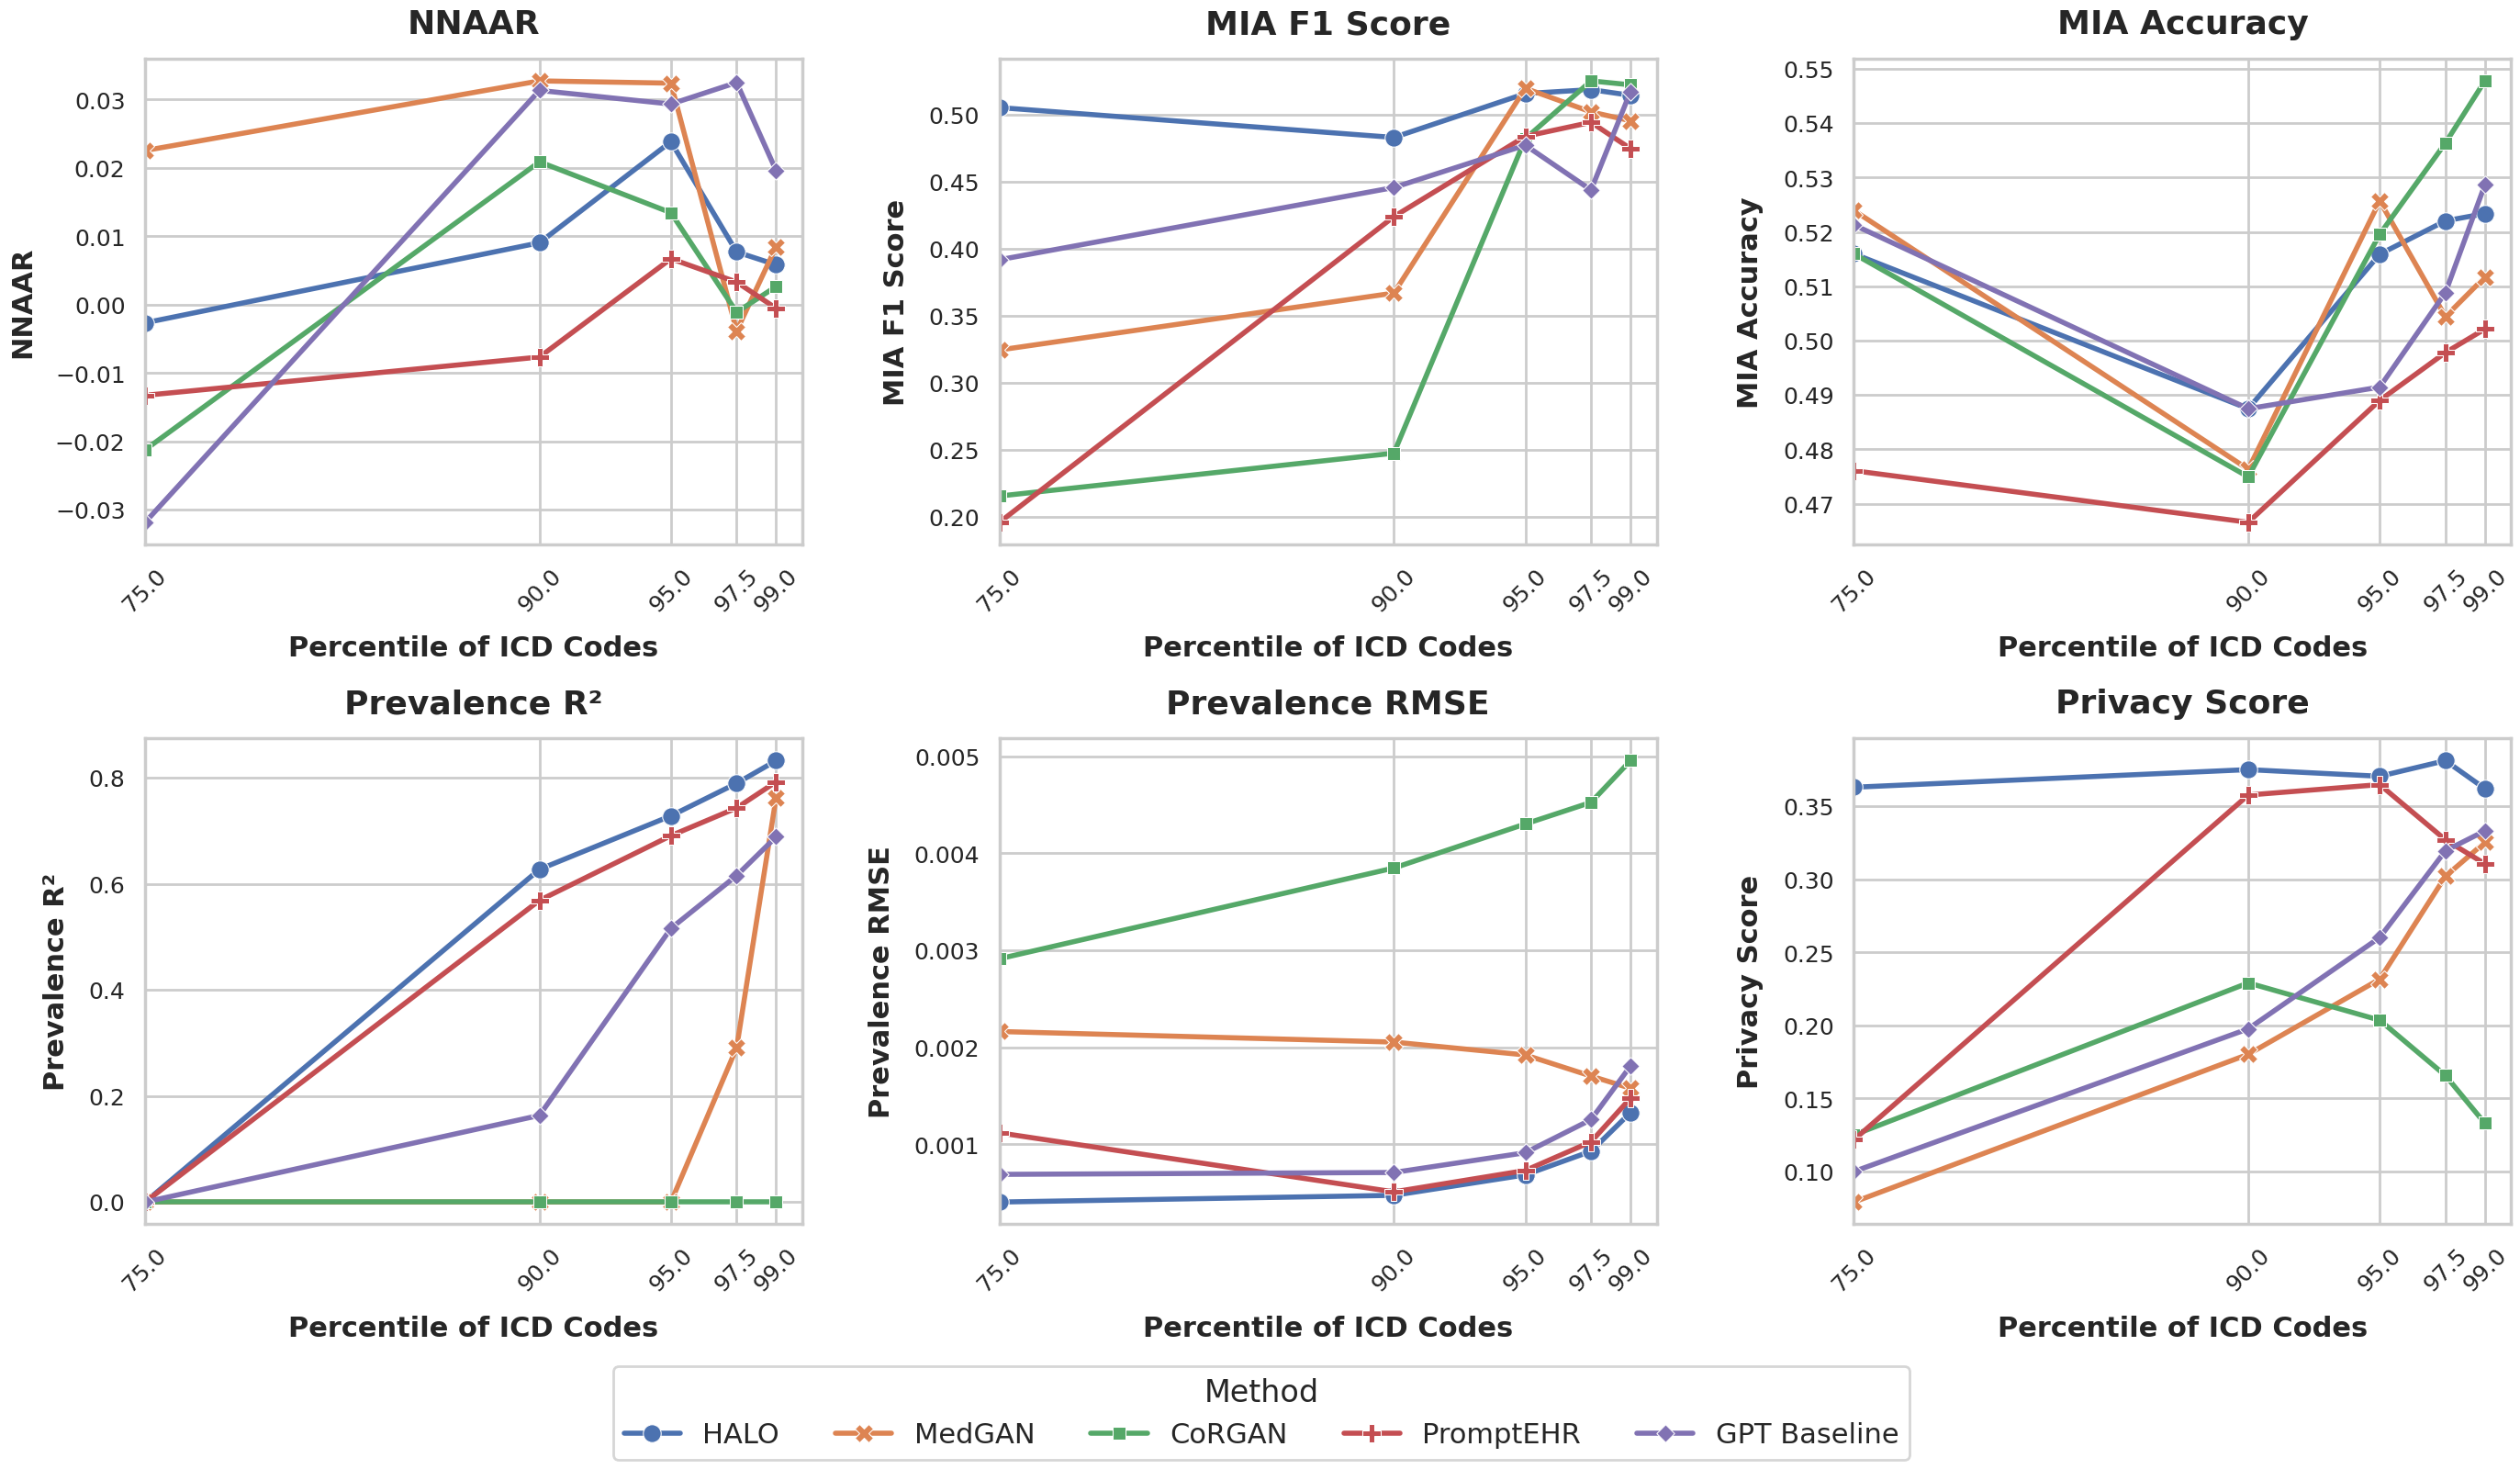

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Data Collection
# ==========================================
# (Assuming data loading logic is here based on your snippet)
percentiles = [75, 90, 95, 97.5, 99]

# 2. Global Style Settings for Larger Text
# ==========================================
# Switch context to 'poster' for significantly larger default fonts (scale=1)
sns.set_theme(style="whitegrid", context="poster", font_scale=1.0)

# Manually override specific font sizes to be even larger/bolder if needed
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titlesize': 24,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20,
    'legend.title_fontsize': 22
})

# Map the exact column names from your CSV to pretty labels
metrics_map = {
    'nnaar': 'NNAAR',
    'MIA_F1': 'MIA F1 Score',
    'MIA_Accuracy': 'MIA Accuracy',
    'Prevalence_R2': 'Prevalence R²',
    'Prevalence_RMSE': 'Prevalence RMSE',
    'Privacy_Score': 'Privacy Score'
}

# Load Data (Placeholder path based on your snippet)
# Ensure this path is correct for your environment
try:
    df = pd.read_csv('./imgs/long_tailed_ablation.csv')
    df['Prevalence_R2'] = df['Prevalence_R2'].clip(lower=0) 
except FileNotFoundError:
    # Creating dummy data so the code runs if CSV is missing
    print("CSV not found, creating dummy data for demonstration...")
    import numpy as np
    data = []
    methods = ['synthetic_10k_halo', 'synthetic_10k_medgan', 'synthetic_10k_corgan']
    for m in methods:
        for p in percentiles:
            data.append([m, p, np.random.rand(), np.random.rand(), np.random.rand(), np.random.rand(), np.random.rand(), np.random.rand()])
    df = pd.DataFrame(data, columns=['method', 'long_tailed_percentile'] + list(metrics_map.keys()))

# Map method names
method_mapping = {
    'synthetic_10k_halo': 'HALO',
    'synthetic_10k_medgan': 'MedGAN',
    'synthetic_10k_corgan': 'CoRGAN',
    'synthetic_10k_promptehr': 'PromptEHR',
    'transformer_baseline_synthetic_ehr': 'GPT Baseline'
}
df['method'] = df['method'].apply(lambda x: method_mapping.get(x, x))


# 3. Generate Plots
# ==========================================
# Increase figsize to ensure large text doesn't crowd the plot
fig, axes = plt.subplots(2, 3, figsize=(28, 16))
axes = axes.flatten()

for i, (col_name, title) in enumerate(metrics_map.items()):
    ax = axes[i]
    
    if col_name in df.columns:
        sns.lineplot(
            data=df,
            x='long_tailed_percentile',
            y=col_name,
            hue='method',
            style='method',
            markers=True,
            dashes=False,
            markersize=14,  # Increased marker size
            ax=ax,
            linewidth=4.0   # Thicker lines
        )
        
        # Formatting with explicit large font sizes
        ax.set_title(title, fontweight='bold', pad=20, fontsize=26)
        ax.set_xlabel("Percentile of ICD Codes", fontweight='bold', labelpad=15, fontsize=22)
        ax.set_ylabel(title, fontweight='bold', labelpad=15, fontsize=22)
        
        # Ticks
        ax.set_xticks(percentiles)
        ax.tick_params(axis='x', rotation=45, labelsize=18)
        ax.tick_params(axis='y', labelsize=18)
        
        ax.set_xlim(75, 100)
        
        # Remove individual legends
        if ax.get_legend():
            ax.get_legend().remove()
    else:
        ax.text(0.5, 0.5, f"{col_name} not found", ha='center', va='center', fontsize=20)

# 4. Final Layout Adjustments
# ==========================================
# Create a single shared legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()

if handles:
    fig.legend(
        handles, 
        labels, 
        loc='lower center', 
        bbox_to_anchor=(0.5, -0.02), # Push slightly higher or lower based on needs
        ncol=len(labels),
        frameon=True,
        title="Method",
        fontsize=22,           # Large legend text
        title_fontsize=24      # Large legend title
    )

plt.tight_layout()

# Adjust bottom margin to make room for the very large legend
plt.subplots_adjust(bottom=0.15, hspace=0.4, wspace=0.3) 

plt.savefig('./imgs/long_tailed_ablation_plots.pdf', bbox_inches='tight')
plt.show()